# Model Evaluation

In [2]:
# TODO: Remove unused libraries

In [6]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import pytorch_lightning as pl
from pytorch_lightning import Trainer

from sklearn.metrics import (
    confusion_matrix, classification_report, 
    balanced_accuracy_score, f1_score,
    precision_score, recall_score
)

print("✓ Imports successful")

✓ Imports successful


In [14]:
%matplotlib inline

In [15]:
import os
SCRATCH = os.getenv("SCRATCH")
EVAL_ROOT = Path(f"{SCRATCH}/team1/data/T33VWH/evaluation")

### Import Evaluation Data (test predictions)

In [16]:
from pathlib import Path
import numpy as np

EVAL_PATH = Path(EVAL_ROOT) / "evaluation_outputs.npz"

data = np.load(EVAL_PATH, allow_pickle=True)

y_true = data["y_true"]
y_pred = data["y_pred"]
class_names = data["class_names"].tolist()

n_classes = len(class_names)

print(f"Test set: {len(y_true)} samples, {n_classes} classes")
print(f"Ground truth distribution: {np.bincount(y_true, minlength=n_classes)}")
print(f"Prediction distribution:  {np.bincount(y_pred, minlength=n_classes)}")
print(class_names)

Test set: 7996 samples, 8 classes
Ground truth distribution: [  72 5294  114  107  994  170  757  488]
Prediction distribution:  [   3    0    0   14 7851  111    0   17]
['broad_leaved_forest', 'coniferous_forest', 'discontinuous_urban_fabric', 'mixed_forest', 'non_irrigated_arable_land', 'peat_bogs', 'transitional_woodland_shrub', 'water_bodies']


### Evaluation Functions

- Overall Accuracy: % of all correct predictions
- Balanced Accuracy: Mean recall per class (immune to imbalance)
- Macro-F1: Mean F1 per class

In [17]:
def _confusion_matrix(y_true, y_pred):
    """Build confusion matrix handling arbitrary class labels."""
    labels = np.unique(np.concatenate([y_true, y_pred]))
    label_to_idx = {int(lbl): i for i, lbl in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[label_to_idx[int(t)], label_to_idx[int(p)]] += 1
    return labels, cm

In [18]:
def _imbalanced_metrics_from_cm(cm):
    """Compute balanced accuracy, macro-F1, and per-class metrics from confusion matrix."""
    tp = np.diag(cm).astype(np.float64)
    support = cm.sum(axis=1).astype(np.float64)
    pred_count = cm.sum(axis=0).astype(np.float64)

    recall = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
    precision = np.divide(tp, pred_count, out=np.zeros_like(tp), where=pred_count > 0)
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(tp),
        where=(precision + recall) > 0,
    )

    balanced_acc = recall.mean()
    macro_f1 = f1.mean()
    overall_acc = tp.sum() / cm.sum() if cm.sum() > 0 else 0.0
    return overall_acc, balanced_acc, macro_f1, recall, precision, f1

### Compute Overall Metrics

In [19]:
labels, cm = _confusion_matrix(y_true, y_pred)
overall_acc, balanced_acc, macro_f1, recall, precision, f1 = _imbalanced_metrics_from_cm(cm)

print("Overall Metrics:")
print(f"  Overall Accuracy:  {overall_acc:.4f}")
print(f"  Balanced Accuracy: {balanced_acc:.4f}")
print(f"  Macro-F1:          {macro_f1:.4f}")
print(f"  Gap (Acc - Bal):   {overall_acc - balanced_acc:.4f}")

# Majority baseline
vals, cnts = np.unique(y_true, return_counts=True)
majority_baseline = cnts.max() / len(y_true)
print(f"\nMajority baseline:  {majority_baseline:.4f}")
print(f"Model improvement:  {balanced_acc - majority_baseline:.4f}")

Overall Metrics:
  Overall Accuracy:  0.1256
  Balanced Accuracy: 0.1370
  Macro-F1:          0.0450
  Gap (Acc - Bal):   -0.0114

Majority baseline:  0.6621
Model improvement:  -0.5251


### Per-Class Metrics

In [20]:
class_names = [f"Class {i}" for i in range(n_classes)]

report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

     Class 0     0.0000    0.0000    0.0000        72
     Class 1     0.0000    0.0000    0.0000      5294
     Class 2     0.0000    0.0000    0.0000       114
     Class 3     0.1429    0.0187    0.0331       107
     Class 4     0.1257    0.9930    0.2232       994
     Class 5     0.1261    0.0824    0.0996       170
     Class 6     0.0000    0.0000    0.0000       757
     Class 7     0.0588    0.0020    0.0040       488

    accuracy                         0.1256      7996
   macro avg     0.0567    0.1370    0.0450      7996
weighted avg     0.0238    0.1256    0.0305      7996



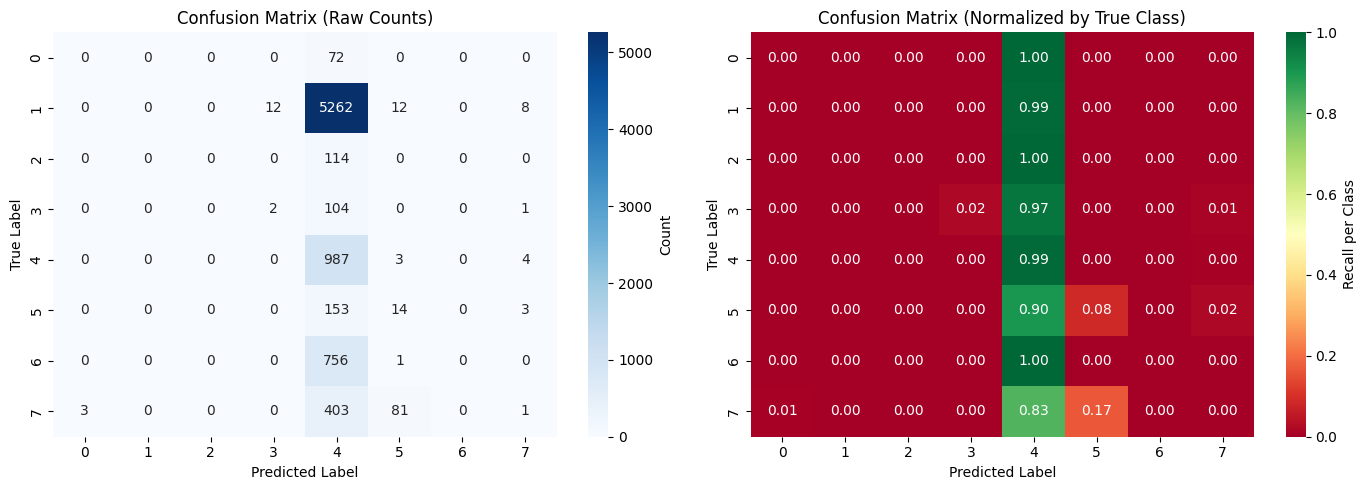

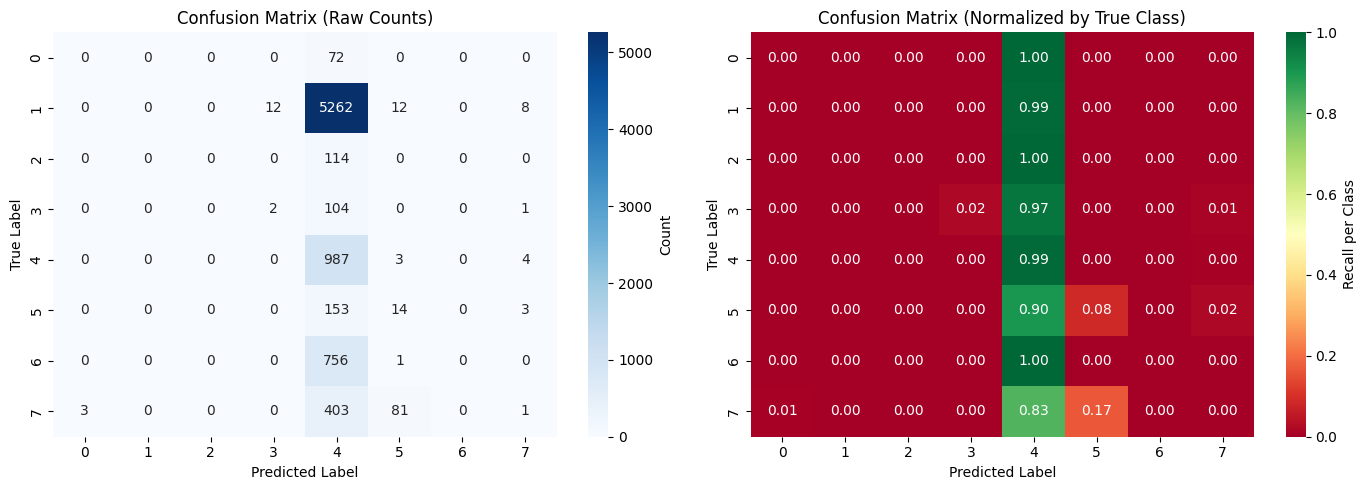

Diagonal = correct predictions per class
Dark values in confusion matrix indicate accurate predictions


In [21]:
cm = confusion_matrix(y_true, y_pred, labels=range(n_classes))
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'},
            xticklabels=range(n_classes), yticklabels=range(n_classes),
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Raw Counts)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label': 'Recall per Class'},
            xticklabels=range(n_classes), yticklabels=range(n_classes),
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized by True Class)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("Diagonal = correct predictions per class")
print("Dark values in confusion matrix indicate accurate predictions")

### Class Distribution Analysis

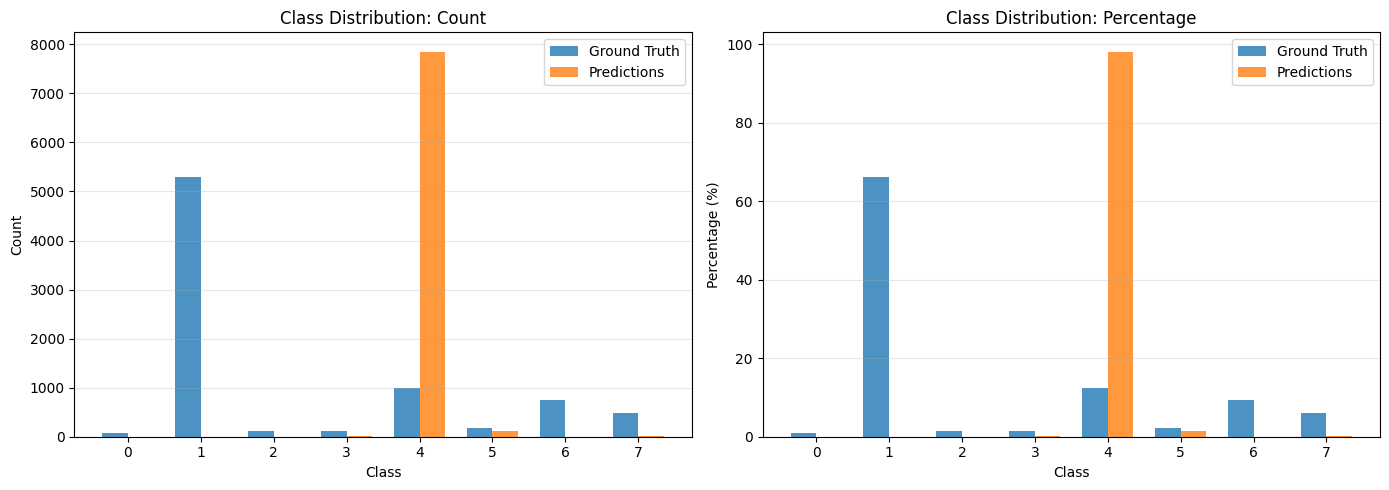

Class    True %       Pred %       Difference  
--------------------------------------------------
0               0.9%        0.0%       -0.9%
1              66.2%        0.0%      -66.2%
2               1.4%        0.0%       -1.4%
3               1.3%        0.2%       -1.2%
4              12.4%       98.2%      +85.8%
5               2.1%        1.4%       -0.7%
6               9.5%        0.0%       -9.5%
7               6.1%        0.2%       -5.9%


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

true_dist = pd.Series(y_true).value_counts().sort_index()
pred_dist = pd.Series(y_pred).value_counts().sort_index()

for i in range(n_classes):
    if i not in true_dist.index:
        true_dist[i] = 0
    if i not in pred_dist.index:
        pred_dist[i] = 0

true_dist = true_dist.sort_index()
pred_dist = pred_dist.sort_index()

# Count plot
x_pos = np.arange(n_classes)
width = 0.35
axes[0].bar(x_pos - width/2, true_dist.values, width, label='Ground Truth', alpha=0.8)
axes[0].bar(x_pos + width/2, pred_dist.values, width, label='Predictions', alpha=0.8)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution: Count')
axes[0].set_xticks(x_pos)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Percentage plot
true_pct = 100 * true_dist / true_dist.sum()
pred_pct = 100 * pred_dist / pred_dist.sum()

axes[1].bar(x_pos - width/2, true_pct.values, width, label='Ground Truth', alpha=0.8)
axes[1].bar(x_pos + width/2, pred_pct.values, width, label='Predictions', alpha=0.8)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Class Distribution: Percentage')
axes[1].set_xticks(x_pos)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{'Class':<8} {'True %':<12} {'Pred %':<12} {'Difference':<12}")
print("-" * 50)
for i in range(n_classes):
    diff = pred_pct.iloc[i] - true_pct.iloc[i]
    print(f"{i:<8} {true_pct.iloc[i]:>10.1f}% {pred_pct.iloc[i]:>10.1f}% {diff:>+10.1f}%")